In [15]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import os

In [16]:
train_dir = r"C:\Users\Asus\Downloads\archive (5)\Training"
test_dir = r"C:\Users\Asus\Downloads\archive (5)\Testing"

In [17]:
import os

print("Train Exists:", os.path.exists(train_dir))
print("Test Exists:", os.path.exists(test_dir))

print(os.listdir(train_dir))

Train Exists: True
Test Exists: True
['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [18]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

In [19]:
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.
Found 394 images belonging to 4 classes.


In [20]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4,activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\Asus\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
from tensorflow.keras.models import Sequential
print(Sequential)

<class 'keras.src.models.sequential.Sequential'>


In [22]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10

    
)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.4414 - loss: 1.2385 - val_accuracy: 0.4485 - val_loss: 1.2435
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.5664 - loss: 1.0040 - val_accuracy: 0.4747 - val_loss: 1.1163
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.6378 - loss: 0.8407 - val_accuracy: 0.5236 - val_loss: 1.0455
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.7027 - loss: 0.7376 - val_accuracy: 0.5916 - val_loss: 0.9305
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.7183 - loss: 0.6719 - val_accuracy: 0.5428 - val_loss: 1.0751
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.7292 - loss: 0.6443 - val_accuracy: 0.5829 - val_loss: 0.8931
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.7593 - loss: 0.6123 - val_accuracy: 0.6335 - val_loss: 0.8710
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.7588 - loss: 0.5920 - val_accuracy: 0.6143 - val_los

In [24]:
loss, accuracy = model.evaluate(test_data)
print("Test Accuracy:", accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step - accuracy: 0.4670 - loss: 2.8625
Test Accuracy: 0.46700507402420044


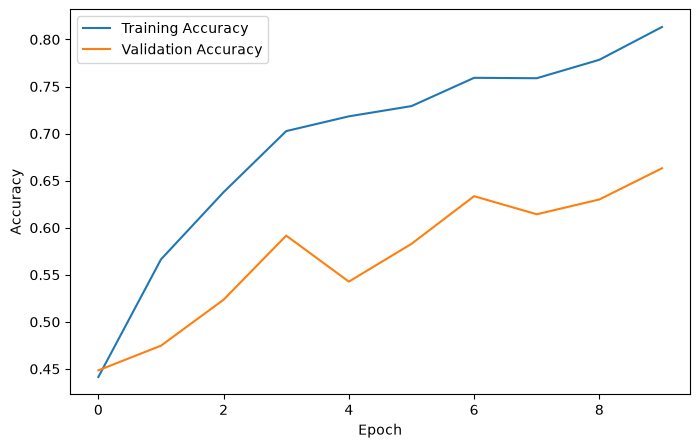

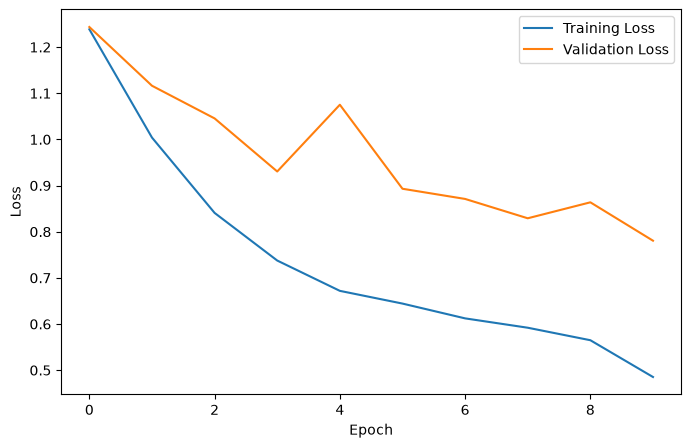

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [27]:
model.save("brain_tumor_model.keras")